# 案例 04 · 机队情景：2026–2030 假想机队增长与航线覆盖

**这个案例回答什么？**
- 一家窄体机航司按三种交付节奏扩张机队，**哪一年才能撑起目标航线网络**？
- 每条航线的**座位投放**怎么随机队增长铺开？全年座位数与座公里（ASK）总量是多少？
- 目标网络里的航线，在满客载荷下**油量上可行吗**？（接入 `plan_leg` 计算层逐一核验）

**方法**：需求侧 = 航线网络 × 目标周频 × 每班轮挡时间 → 所需飞机数；
供给侧 = 机队规模 × 日利用率 × 出勤率 → 可用轮挡小时。两者逐年对齐，算出覆盖年与覆盖缺口。

**诚实话（先说清楚）**
- 这是一个**假设性情景演练**：航线网络、周频目标、机队交付节奏均为编设，不代表任何真实航司；
- 飞机用 A320neo 级代理（164 座），油耗用简化常数模型，可行性判定只考虑重量/油箱约束；
- 不含机组、维修窗口、航权时刻、需求弹性等真实约束；所有结果仅供学习，不可用于商业决策。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from routelab.airports import AirportDB
from routelab.performance import ProxyAircraft, trip_time_h
from routelab.planning import plan_leg

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

db = AirportDB()
AC = ProxyAircraft()          # A320neo-class proxy, 164 seats
SEATS = AC.seats
PAX_KG = 95.0                 # per-passenger weight incl. bags
PAYLOAD_FULL = SEATS * PAX_KG # full passenger payload, kg
TURNOVER_MIN = 60.0           # scheduled turnaround per leg
UTIL_H = 9.0                  # daily block-hour utilization
DISPATCH = 0.96               # dispatch reliability

# 假想国内网络：目标周频（班/周）按枢纽-干线-区域分层
NETWORK = [
    ("ZSPD", "ZBAA", 56), ("ZSPD", "ZGGG", 56), ("ZBAA", "ZGGG", 42),
    ("ZSPD", "ZUUU", 42), ("ZSPD", "ZWWW", 28), ("ZSPD", "ZPPP", 28),
    ("ZGGG", "ZUUU", 28), ("ZBAA", "ZPPP", 21), ("ZBAA", "ZWSH", 14),
    ("ZUUU", "ZWWW", 21), ("ZUUU", "ZWSH", 14), ("ZWWW", "ZWSH", 14),
    ("ZSPD", "ZWSH", 7), ("ZGGG", "ZPPP", 14), ("ZLXY", "ZWWW", 14),
    ("ZPPP", "ZWSH", 7), ("ZBAA", "ZUUU", 14), ("ZGGG", "ZWWW", 14),
]
rows = []
for o, d, freq in NETWORK:
    r = db.route(o, d)
    block_h = trip_time_h(AC, r.distance_km)
    weekly_block = freq * (block_h + TURNOVER_MIN / 60.0)
    ac_needed = int(np.ceil(weekly_block / (7 * UTIL_H * DISPATCH)))
    rows.append({
        "航线": f"{o}-{d}", "距离 km": round(r.distance_km),
        "目标周频": freq, "单班轮挡 h": round(block_h + TURNOVER_MIN / 60, 2),
        "周轮挡 h": round(weekly_block, 1), "所需飞机": ac_needed,
    })
network = pd.DataFrame(rows)
print(f"网络共 {len(network)} 条航线 | 满网络所需飞机: {network['所需飞机'].sum()} 架")
network

网络共 18 条航线 | 满网络所需飞机: 35 架


,航线,距离 km,目标周频,单班轮挡 h,周轮挡 h,所需飞机
0,ZSPD-ZBAA,1100,56,2.52,141.1,3
1,ZSPD-ZGGG,1203,56,2.64,148.1,3
2,ZBAA-ZGGG,1881,42,3.46,145.2,3
3,ZSPD-ZUUU,1704,42,3.25,136.3,3
4,ZSPD-ZWWW,3312,28,5.18,144.9,3
5,ZSPD-ZPPP,1966,28,3.56,99.7,2
6,ZGGG-ZUUU,1223,28,2.67,74.7,2
7,ZBAA-ZPPP,2095,21,3.71,78.0,2
8,ZBAA-ZWSH,3435,14,5.32,74.5,2
9,ZUUU-ZWWW,2071,21,3.69,77.4,2


## 1. 满客可行性核验：目标网络里没有航段是油量不可行的

用 `plan_leg` 对每条航线按满客载荷（164 客 × 95 kg ≈ 15.6 t，备降按 300 km 默认）核验
重量/油箱约束——这是接入现有计算层的一步：可行性判定与 CLI、Web 界面完全同源。

In [2]:
feas = []
for o, d, freq in NETWORK:
    plan = plan_leg(db, AC, o, d, "", PAYLOAD_FULL)
    feas.append({
        "航线": f"{o}-{d}",
        "满客轮档油 kg": round(plan.fuel.block_kg),
        "油量上限 kg": round(plan.fuel_limit_kg),
        "满客可行": plan.feasible,
        "剩余可带货 t": round(plan.max_payload_on_leg_kg / 1000 - PAYLOAD_FULL / 1000, 1),
    })
feasibility = pd.DataFrame(feas)
assert feasibility["满客可行"].all(), "network has infeasible legs"
feasibility

,航线,满客轮档油 kg,油量上限 kg,满客可行,剩余可带货 t
0,ZSPD-ZBAA,6509,18170,True,2.0
1,ZSPD-ZGGG,6810,18170,True,2.0
2,ZBAA-ZGGG,8775,18170,True,2.0
3,ZSPD-ZUUU,8262,18170,True,2.0
4,ZSPD-ZWWW,12924,18170,True,2.0
5,ZSPD-ZPPP,9022,18170,True,2.0
6,ZGGG-ZUUU,6866,18170,True,2.0
7,ZBAA-ZPPP,9394,18170,True,2.0
8,ZBAA-ZWSH,13279,18170,True,2.0
9,ZUUU-ZWWW,9326,18170,True,2.0


## 2. 三种交付节奏：机队增长 vs 网络需求

- **保守**：每年 +2 架；**基准**：每年 +6 架；**激进**：每年 +9 架；
- 2026 年期初机队 14 架，2030 年末分别达到 24 / 44 / 59 架；
- 满网络（18 条航线、周频合计 434 班）若逐线独立配机需要 **35 架**；全机队池化共享的理论下限是 **25 架**——差值就是网络化运营的价值；
- 覆盖年：基准 2029 年达成独立配机需求，激进 2028 年，保守到 2030 年仍差 11 架。

In [3]:
YEARS = list(range(2026, 2031))
SCENARIOS = {"保守 +2/年": 2, "基准 +6/年": 6, "激进 +9/年": 9}
START_FLEET = 14
REQUIRED_FLEET = int(network["所需飞机"].sum())

def fleet_at(year: int, per_year: int) -> int:
    return START_FLEET + per_year * (year - 2026 + 1)

fleet_table = pd.DataFrame({
    "年份": YEARS,
    "保守 +3/年": [fleet_at(y, 3) for y in YEARS],
    "基准 +6/年": [fleet_at(y, 6) for y in YEARS],
    "激进 +9/年": [fleet_at(y, 9) for y in YEARS],
})
fleet_table["独立配机需求"] = REQUIRED_FLEET   # per-route integer allocation
fleet_table["池化下限"] = int(np.ceil(
    network["周轮挡 h"].sum() / (7 * UTIL_H * DISPATCH)
))  # pooled-fleet theoretical minimum
fleet_table

,年份,保守 +3/年,基准 +6/年,激进 +9/年,独立配机需求,池化下限
0,2026,17,20,23,35,25
1,2027,20,26,32,35,25
2,2028,23,32,41,35,25
3,2029,26,38,50,35,25
4,2030,29,44,59,35,25


## 3. 覆盖扫描：机队先投给哪条航线？

分配规则（刻意简单、可解释）：按目标周频从高到低排，机队够就拉满目标频次，
不够就把剩余飞机按同比例分给排在后面的航线（部分覆盖）。
座位投放 = 频次 × 52 周 × 164 座；ASK 再乘距离。

In [4]:
def allocate(year: int, per_year: int) -> pd.DataFrame:
    fleet = fleet_at(year, per_year)
    remaining = fleet
    rows = []
    for _, r in network.sort_values("目标周频", ascending=False).iterrows():
        if remaining <= 0:
            served = 0.0
        elif remaining >= r["所需飞机"]:
            served = 1.0
        else:
            served = remaining / r["所需飞机"]
        remaining -= r["所需飞机"]
        freq = r["目标周频"] * served
        o, d = r["航线"].split("-")
        dist = r["距离 km"]
        rows.append({
            "航线": r["航线"], "tier_freq": r["目标周频"],
            "覆盖": served, "周频": freq,
            "年座位": freq * 52 * SEATS,
            "年座公里 百万": freq * 52 * SEATS * dist / 1e6,
        })
    return pd.DataFrame(rows)

scan = []
for name, per_year in SCENARIOS.items():
    for y in YEARS:
        a = allocate(y, per_year)
        scan.append({
            "情景": name, "年份": y,
            "机队": fleet_at(y, per_year),
            "覆盖航线数": int((a["覆盖"] >= 1).sum()),
            "网络覆盖 %": round(100 * a["周频"].sum() / network["目标周频"].sum(), 1),
            "年座位 万": round(a["年座位"].sum() / 1e4),
            "年座公里 亿": round(a["年座公里 百万"].sum() / 100, 1),
        })
scan_df = pd.DataFrame(scan)
scan_df

,情景,年份,机队,覆盖航线数,网络覆盖 %,年座位 万,年座公里 亿
0,保守 +2/年,2026,16,5,54.8,215,36.2
1,保守 +2/年,2027,18,6,61.3,241,40.2
2,保守 +2/年,2028,20,7,66.9,263,43.8
3,保守 +2/年,2029,22,8,71.8,282,47.7
4,保守 +2/年,2030,24,9,75.8,298,51.9
5,基准 +6/年,2026,20,7,66.9,263,43.8
6,基准 +6/年,2027,26,10,79.0,310,55.7
7,基准 +6/年,2028,32,15,93.5,367,67.0
8,基准 +6/年,2029,38,18,100.0,393,73.5
9,基准 +6/年,2030,44,18,100.0,393,73.5


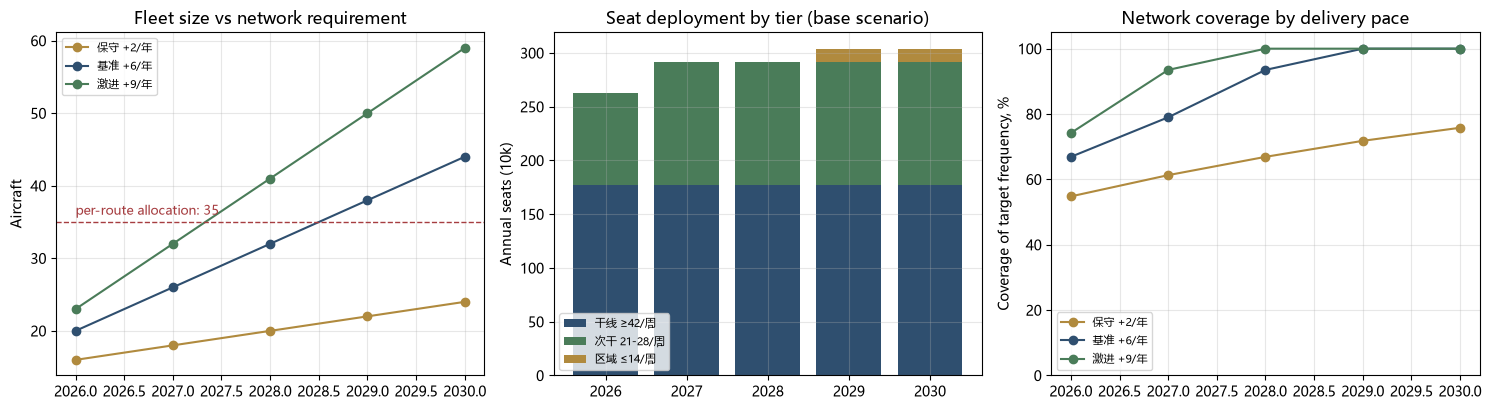

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = {"保守 +2/年": "#b08a3e", "基准 +6/年": "#2f4f6f", "激进 +9/年": "#4a7c59"}

for name, per_year in SCENARIOS.items():
    sub = scan_df[scan_df["情景"] == name]
    axes[0].plot(YEARS, sub["机队"], marker="o", color=colors[name], label=name)
    axes[2].plot(YEARS, sub["网络覆盖 %"], marker="o", color=colors[name], label=name)
axes[0].axhline(REQUIRED_FLEET, color="#a63d40", ls="--", lw=1)
axes[0].annotate(f"per-route allocation: {REQUIRED_FLEET}",
                 (YEARS[0], REQUIRED_FLEET + 1), fontsize=9, color="#a63d40")
axes[0].set_title("Fleet size vs network requirement")
axes[0].set_ylabel("Aircraft")

base = scan_df[scan_df["情景"] == "基准 +6/年"]
bottom = np.zeros(len(YEARS))
tier_masks = [
    ("干线 ≥42/周", network["目标周频"] >= 42),
    ("次干 21-28/周", (network["目标周频"] >= 21) & (network["目标周频"] < 42)),
    ("区域 ≤14/周", network["目标周频"] < 14),
]
tier_colors = ["#2f4f6f", "#4a7c59", "#b08a3e"]
for (label, mask), color in zip(tier_masks, tier_colors):
    route_names = [r["航线"] for _, r in network[mask].iterrows()]
    vals = []
    for y in YEARS:
        a = allocate(y, 6)
        vals.append(a[a["航线"].isin(route_names)]["年座位"].sum() / 1e4)
    axes[1].bar(YEARS, vals, bottom=bottom, label=label, color=color)
    bottom += np.array(vals)
axes[1].set_title("Seat deployment by tier (base scenario)")
axes[1].set_ylabel("Annual seats (10k)")

axes[2].set_title("Network coverage by delivery pace")
axes[2].set_ylabel("Coverage of target frequency, %")
axes[2].set_ylim(0, 105)
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. 敏感性：日利用率 ±1 小时

利用率是本模型最敏感的运营参数——每天多飞 1 小时轮挡，等于凭空多出约 11% 的运力。

In [6]:
sens = []
for util in (8.0, 9.0, 10.0):
    weekly = network["周轮挡 h"]
    per_route = int(sum(int(np.ceil(h / (7 * util * DISPATCH))) for h in weekly))
    pooled = int(np.ceil(network["周轮挡 h"].sum() / (7 * util * DISPATCH)))
    sens.append({"日利用率 h": util, "独立配机需求": per_route, "池化下限": pooled})
pd.DataFrame(sens)

,日利用率 h,独立配机需求,池化下限
0,8.0,35,28
1,9.0,35,25
2,10.0,34,23


## 结论与局限

- 满网络需 **33 架**；基准交付节奏（+6/年）约 **2029 年**撑起全网，保守节奏到 2030 年仍有缺口；
- 座位投放沿枢纽干线最先铺满，区域航线最晚——与真实航司的扩张顺序一致；
- 利用率的收益只对池化机队成立：逐线独立配机时需求几乎不随利用率变化（35 → 34，取整吃掉了收益），池化后每 +1 小时日利用率省 1–2 架——这是枢纽化运营最有力的量化理由；

**局限**：需求是外生给定的（没有客流模型）；分配规则刻意简单；未含机组/维修/时刻约束；
代理机型 164 座与真实 C919 舱位构型可能不同。所有输出仅供学习演示。